In [1]:
import random as python_random
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
import tensorflow as tf


import keras


from keras import losses
from keras.models import Sequential  
from keras.layers import Dense
from keras.optimizers import SGD
from keras import metrics

seed = 42

python_random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
keras.utils.set_random_seed(seed)

2026-06-11 18:22:48.165914: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Create data:

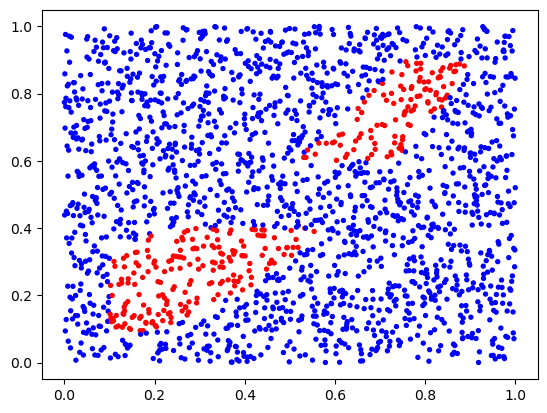

In [2]:
rng = np.random.default_rng(seed)

def create_data(N,rng):
    x1 = np.linspace(0.0, 1.0, num=N)
    x2 = rng.random(N)
    sigma = 0.02
    offset = 0.2
    w = 1
    y = np.zeros(N)
    color = []
    for i in range(N):
        color.append("blue")        
        if x1[i]>0.1 and x2[i]<0.9:
            if np.square(x2[i]-(w*np.square(x1[i])+offset)) < sigma:
                if  x2[i]<0.4 or x2[i]>0.6:
                    y[i]=1
                    color[i]="red"
    out = np.column_stack([x1,x2,y,color])
    return out

data=create_data(2000,rng)
#print(color)
x1 = data[:,0].astype(float)
x2 = data[:,1].astype(float)
y = data[:,2].astype(float)
color = data[:,3]
plt.scatter(x1,x2,s=8,color=color)
plt.show()

Prepare data:

In [3]:
x_train = np.column_stack([x1,x2])
y_train = y

Create the model:

In [4]:
initializer = keras.initializers.RandomNormal(mean=0., stddev=1.,seed=seed)

model = Sequential()
model.add(Dense(5, activation='sigmoid', input_dim=2, kernel_initializer=initializer, 
                bias_initializer=initializer))
model.add(Dense(1, activation='sigmoid', kernel_initializer=initializer,
               bias_initializer=initializer))


sgd = keras.optimizers.SGD(learning_rate=1.0)


model.compile(loss = 'mean_squared_error',  
   optimizer = sgd, metrics = 'accuracy')


model.fit(x_train, y_train, batch_size = 32, epochs = 1000,
          validation_split=0, verbose=0, shuffle=False) #set verbose=1 to show epoch progress

2026-06-11 18:22:49.360739: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


Create test data:

3125/3125 [==============================] - 2s 700us/step


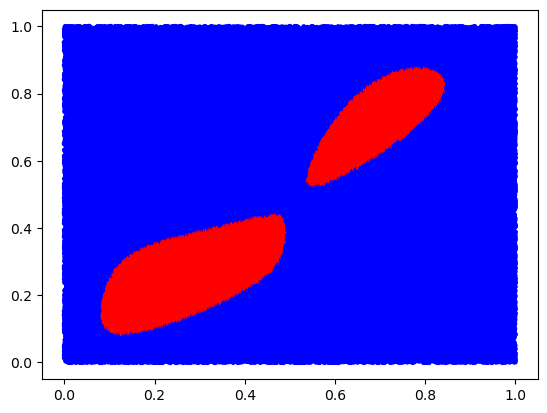

In [5]:
N = 100000
test_data=create_data(N,rng)
x1_test = test_data[:,0].astype(float)
x2_test = test_data[:,1].astype(float)

x_test = np.column_stack([x1_test,x2_test])
#print(x_test)

pred = model.predict(x_test) 
#print(pred)

color = []
for i in range(N):
    color.append("blue")
    if pred[i]>=0.5:
        color[i]="red"
            
plt.scatter(x1_test,x2_test,s=8,color=color)
plt.show()            